## fit_transform() and transform()

### 1. What is fit()?

- `fit()` **learns the parameters from the training data**.

- It does not **change the data**, it only calculates statistics required for transformation.

## 2. What is transform()?

- `transform()` **applies the learned parameters to convert the data**.

- It uses the knowledge learned during fit().

## 3. What is fit_transform()?

- `fit_transform()` performs both steps together:

1. Learn parameters from the data
2. Apply transformation

   - `fit + transform`

## 4. `transform()` Applying to Test Data

For test data, we should NOT learn new parameters.

We only apply the existing transformation.

Why?

Because the model must use training statistics.

In [31]:
import pandas as pd


In [32]:
df = pd.read_csv(r"C:\Users\DELL\Desktop\Classes\Machine Learning\Datasets\customer_encoding.csv")

In [3]:
df.head()

,age,gender,review,education,purchased
0,30,Female,Average,School,No
1,68,Female,Poor,UG,No
2,70,Female,Good,PG,No
3,72,Female,Good,PG,No
4,16,Female,Average,UG,No


### 1. One-Hot Encoding

- One-Hot Encoding converts each category into a separate binary column (0 or 1).
  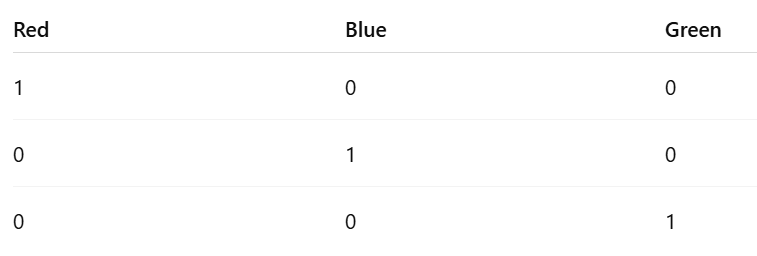
- Use when categories have **no natural order**

In [4]:
import sklearn


In [5]:
from sklearn.preprocessing import OneHotEncoder

In [6]:
ohe = OneHotEncoder(sparse_output=False)
gender_ohe = ohe.fit_transform(df[["gender"]])

In [7]:

pd.DataFrame(gender_ohe,columns=["Male","Female"])

,Male,Female
0,1.0,0.0
1,1.0,0.0
2,1.0,0.0
3,1.0,0.0
4,1.0,0.0
5,1.0,0.0
6,0.0,1.0
7,1.0,0.0
8,1.0,0.0
9,0.0,1.0


#### Problems
- Curse of dimensionality when categories are large
- Creates many columns
    - Example: 500 cities → 500 features

### 2. Label Encoding
- Label Encoding assigns a **unique integer to each category**
- Use when:

    - Encoding target variable
    - Tree-based models

In [8]:
from sklearn.preprocessing import LabelEncoder

In [9]:
le = LabelEncoder()
le.fit_transform(df["review"])

array([0, 2, 1, 1, 0, 0, 1, 2, 0, 1, 1, 1, 2, 0, 2, 2, 2, 2, 1, 2, 0, 0,
       2, 1, 0, 1, 2, 2, 2, 0, 0, 2, 0, 1, 0, 2, 1, 0, 1, 2, 1, 1, 1, 2,
       0, 2, 2, 1, 1, 1])

#### Problems

- Model may assume **false ordering**

### 3. Ordinal Encoding

- Ordinal Encoding converts categories into numbers **based on a meaningful order.**
- Ordinal Encoding is a technique used to **convert categorical variables** into numerical values by assigning ordered integers to categories

#### When to Use Ordinal Encoding

1. The categorical feature has **meaningful order**
2. The model can benefit from that **ranking relationship**
3. Categories represent **levels or hierarchy**

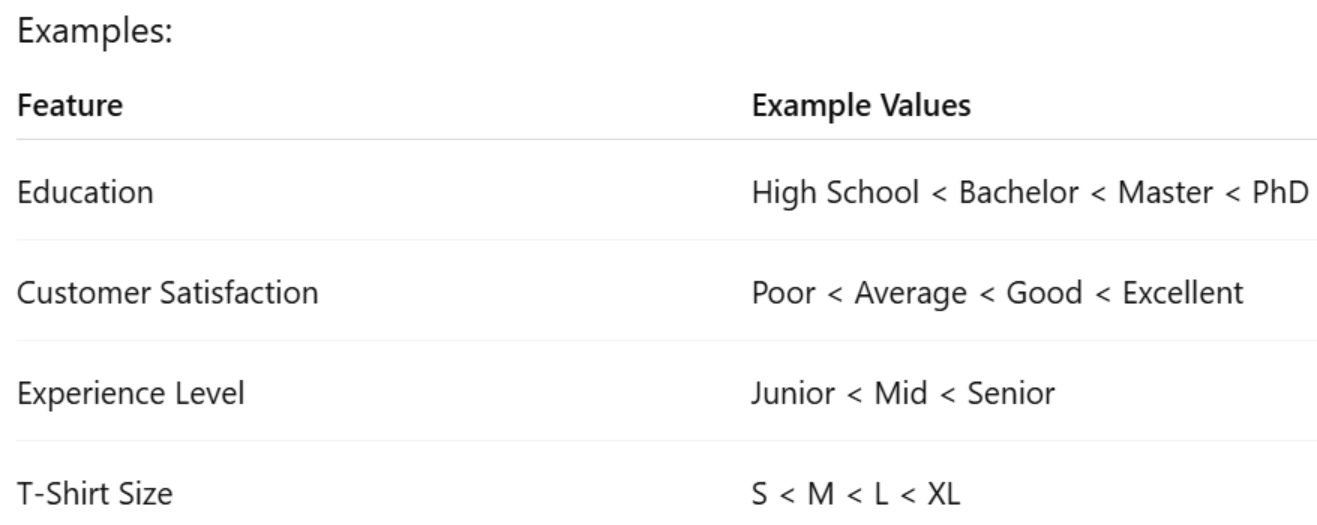

In [10]:
from sklearn.preprocessing import OrdinalEncoder

### Advantages
1. Simple and fast
2. Reduces dimensionality (only one columns)
3. Works well with tree-based models
4. Preserves category order

### Disadvantages
1. Assumes distance between categories is meaningful
2. Can introduce false relationships
3. Not suitable for nominal categorical data
4. Some models may interpret numbers as continuous values

In [11]:
ord_enc = OrdinalEncoder()

In [12]:
ord_enc.fit_transform(df[["review","education"]])

array([[0., 1.],
       [2., 2.],
       [1., 0.],
       [1., 0.],
       [0., 2.],
       [0., 1.],
       [1., 1.],
       [2., 1.],
       [0., 2.],
       [1., 2.],
       [1., 2.],
       [1., 2.],
       [2., 1.],
       [0., 1.],
       [2., 0.],
       [2., 2.],
       [2., 2.],
       [2., 2.],
       [1., 1.],
       [2., 0.],
       [0., 1.],
       [0., 0.],
       [2., 0.],
       [1., 1.],
       [0., 0.],
       [1., 1.],
       [2., 0.],
       [2., 0.],
       [2., 1.],
       [0., 2.],
       [0., 2.],
       [2., 1.],
       [0., 2.],
       [1., 0.],
       [0., 1.],
       [2., 1.],
       [1., 2.],
       [0., 0.],
       [1., 1.],
       [2., 0.],
       [1., 1.],
       [1., 0.],
       [1., 0.],
       [2., 0.],
       [0., 2.],
       [2., 0.],
       [2., 0.],
       [1., 0.],
       [1., 2.],
       [1., 2.]])

This may not match the real logical order

**Specify the Order Manually**

You can define the order explicitly.

In [13]:
df["review"].unique(), df["education"].unique()

(array(['Average', 'Poor', 'Good'], dtype=object),
 array(['School', 'UG', 'PG'], dtype=object))

In [14]:
oe = OrdinalEncoder(categories=[['Poor','Average','Good'],['School','UG','PG']])
oe.fit_transform(df[["review","education"]])

array([[1., 0.],
       [0., 1.],
       [2., 2.],
       [2., 2.],
       [1., 1.],
       [1., 0.],
       [2., 0.],
       [0., 0.],
       [1., 1.],
       [2., 1.],
       [2., 1.],
       [2., 1.],
       [0., 0.],
       [1., 0.],
       [0., 2.],
       [0., 1.],
       [0., 1.],
       [0., 1.],
       [2., 0.],
       [0., 2.],
       [1., 0.],
       [1., 2.],
       [0., 2.],
       [2., 0.],
       [1., 2.],
       [2., 0.],
       [0., 2.],
       [0., 2.],
       [0., 0.],
       [1., 1.],
       [1., 1.],
       [0., 0.],
       [1., 1.],
       [2., 2.],
       [1., 0.],
       [0., 0.],
       [2., 1.],
       [1., 2.],
       [2., 0.],
       [0., 2.],
       [2., 0.],
       [2., 2.],
       [2., 2.],
       [0., 2.],
       [1., 1.],
       [0., 2.],
       [0., 2.],
       [2., 2.],
       [2., 1.],
       [2., 1.]])

**Note : OrdinalEncoder does not understand meaning.
It only assigns numbers based on sorting unless we specify the order.**

Machine learning models do not understand semantics — they only follow the rules we define.

### 4. Get Dummies
- Creates binary columns for each category similar to One-Hot Encoding using **pandas**.

In [32]:
pd.get_dummies(df["education"],drop_first=True,dtype="int")

,School,UG
0,1,0
1,0,1
2,0,0
3,0,0
4,0,1
5,1,0
6,1,0
7,1,0
8,0,1
9,0,1


Does the category have an order?

- YES → Ordinal Encoding

- NO → One-Hot Encoding

- Target variable → Label Encoding

- Quick preprocessing → Get Dummies

In [23]:
import sklearn

In [33]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, OrdinalEncoder, LabelEncoder

In [34]:
df["education"].unique()

array(['School', 'UG', 'PG'], dtype=object)

In [29]:
transformer = ColumnTransformer(transformers=[
    ("OHE",OneHotEncoder(),["gender"]),
    ("OrdEnc",OrdinalEncoder(categories=[["Poor","Average","Good"],['School', 'UG', 'PG']]),["review","education"])    
],remainder="passthrough")

In [35]:
result = transformer.fit_transform(df)

In [36]:
pd.DataFrame(result,columns=["Female","Male","Review","Education","Age","Purchased"])

,Female,Male,Review,Education,Age,Purchased
0,1.0,0.0,1.0,0.0,30,No
1,1.0,0.0,0.0,1.0,68,No
2,1.0,0.0,2.0,2.0,70,No
3,1.0,0.0,2.0,2.0,72,No
4,1.0,0.0,1.0,1.0,16,No
5,1.0,0.0,1.0,0.0,31,Yes
6,0.0,1.0,2.0,0.0,18,No
7,1.0,0.0,0.0,0.0,60,Yes
8,1.0,0.0,1.0,1.0,65,No
9,0.0,1.0,2.0,1.0,74,Yes


## ColumnTransformer()

In [15]:
from sklearn.compose import ColumnTransformer

In [16]:
df.columns

Index(['age', 'gender', 'review', 'education', 'purchased'], dtype='object')

In [48]:
df["purchased"].unique()

array(['No', 'Yes'], dtype=object)

In [21]:
transformer = ColumnTransformer(transformers=[
    ("OHE",OneHotEncoder(sparse_output=False,drop="first"),["gender"]),
    ("OrdEnc",OrdinalEncoder(categories=[['Poor','Average','Good'],['School','UG','PG']]),["review","education"])
],remainder="passthrough")

In [22]:
transformer

,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('OHE', ...), ('OrdEnc', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'passthrough'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transformers contains sparse matrices,these will be stacked as a sparse matrix if the overall density islower than this value. Use ``sparse_threshold=0`` to always returndense. When the transformed output consists of all dense data, thestacked result will be dense, and this keyword will be ignored.",0.3
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details.",None
,"transformer_weights transformer_weights: dict, default=NoneMultiplicative weights for features per transformer. The output of thetransformer is multiplied by these weights. Keys are transformer names,values the weights.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each transformer will beprinted as it is completed.",False
,"verbose_feature_names_out verbose_feature_names_out: bool, str or Callable[[str, str], str], default=True- If True, :meth:`ColumnTransformer.get_feature_names_out` will prefix all feature names with the name of the transformer that generated that feature. It is equivalent to setting `verbose_feature_names_out=""{transformer_name}__{feature_name}""`.- If False, :meth:`ColumnTransformer.get_feature_names_out` will not prefix any feature names and will error if feature names are not unique.- If ``Callable[[str, str], str]``, :meth:`ColumnTransformer.get_feature_names_out` will rename all the features using the name of the transformer. The first argument of the callable is the transformer name and the second argument is the feature name. The returned string will be the new feature name.- If ``str``, it must be a string ready for formatting. The given string will be formatted using two field names: ``transformer_name`` and ``feature_name

In [20]:
transformer.fit_transform(df)

array([[0.0, 1.0, 0.0, 30, 'No'],
       [0.0, 0.0, 1.0, 68, 'No'],
       [0.0, 2.0, 2.0, 70, 'No'],
       [0.0, 2.0, 2.0, 72, 'No'],
       [0.0, 1.0, 1.0, 16, 'No'],
       [0.0, 1.0, 0.0, 31, 'Yes'],
       [1.0, 2.0, 0.0, 18, 'No'],
       [0.0, 0.0, 0.0, 60, 'Yes'],
       [0.0, 1.0, 1.0, 65, 'No'],
       [1.0, 2.0, 1.0, 74, 'Yes'],
       [0.0, 2.0, 1.0, 98, 'Yes'],
       [1.0, 2.0, 1.0, 74, 'Yes'],
       [1.0, 0.0, 0.0, 51, 'No'],
       [0.0, 1.0, 0.0, 57, 'No'],
       [1.0, 0.0, 2.0, 15, 'Yes'],
       [1.0, 0.0, 1.0, 75, 'No'],
       [1.0, 0.0, 1.0, 59, 'Yes'],
       [0.0, 0.0, 1.0, 22, 'Yes'],
       [1.0, 2.0, 0.0, 19, 'No'],
       [1.0, 0.0, 2.0, 97, 'Yes'],
       [0.0, 1.0, 0.0, 57, 'Yes'],
       [1.0, 1.0, 2.0, 32, 'No'],
       [0.0, 0.0, 2.0, 18, 'Yes'],
       [0.0, 2.0, 0.0, 96, 'No'],
       [0.0, 1.0, 2.0, 16, 'Yes'],
       [0.0, 2.0, 0.0, 57, 'No'],
       [0.0, 0.0, 2.0, 53, 'No'],
       [0.0, 0.0, 2.0, 69, 'No'],
       [1.0, 0.0, 0.0, 48, 'No'],
  

In [59]:
pd.DataFrame(transformer.fit_transform(df),columns=["Male","review","education","age","purchage"])

,Male,review,education,age,purchage
0,0.0,1.0,0.0,30,No
1,0.0,0.0,1.0,68,No
2,0.0,2.0,2.0,70,No
3,0.0,2.0,2.0,72,No
4,0.0,1.0,1.0,16,No
5,0.0,1.0,0.0,31,Yes
6,1.0,2.0,0.0,18,No
7,0.0,0.0,0.0,60,Yes
8,0.0,1.0,1.0,65,No
9,1.0,2.0,1.0,74,Yes
